Шлях до метаданих:
 ESC-50/meta/esc50.csv
Папка з аудіофайлами:
 ESC-50/audio
Папка для вихідних даних:
 ESC_subset
----------
Кількість записів у CSV:
 2000
Унікальні класи:
 ['dog' 'chirping_birds' 'vacuum_cleaner' 'thunderstorm' 'door_wood_knock'
 'can_opening' 'crow' 'clapping' 'fireworks' 'chainsaw' 'airplane'
 'mouse_click' 'pouring_water' 'train' 'sheep' 'water_drops'
 'church_bells' 'clock_alarm' 'keyboard_typing' 'wind' 'footsteps' 'frog'
 'cow' 'brushing_teeth' 'car_horn' 'crackling_fire' 'helicopter'
 'drinking_sipping' 'rain' 'insects' 'laughing' 'hen' 'engine' 'breathing'
 'crying_baby' 'hand_saw' 'coughing' 'glass_breaking' 'snoring'
 'toilet_flush' 'pig' 'washing_machine' 'clock_tick' 'sneezing' 'rooster'
 'sea_waves' 'siren' 'cat' 'door_wood_creaks' 'crickets']
----------
Вибрані класи:
 ['dog', 'chirping_birds']
Кількість вибраних файлів:
 80
----------


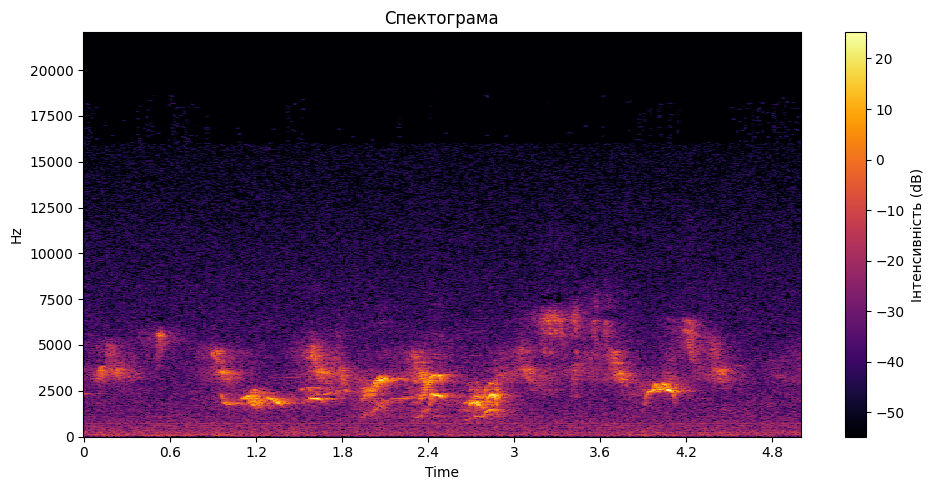

Виведення спектральної матриці:
 [[-29.020966 -44.642643 -41.595768 ... -28.16496  -46.25003  -32.723698]
 [-26.148811 -28.894997 -34.065575 ... -32.772495 -25.612946 -27.997059]
 [-21.983606 -22.654678 -38.566994 ... -24.436167 -23.717802 -24.024122]
 ...
 [-54.830925 -54.830925 -54.830925 ... -54.830925 -54.830925 -54.830925]
 [-54.830925 -54.830925 -54.830925 ... -54.830925 -54.830925 -54.830925]
 [-54.830925 -54.830925 -54.830925 ... -54.830925 -54.830925 -54.830925]]


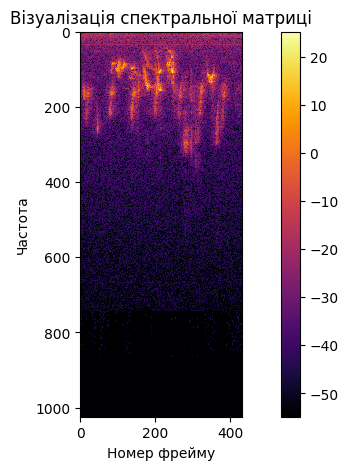

In [21]:
import numpy as np
import pandas as pd
import librosa.display 
import multiprocessing
import matplotlib.pyplot as plt
import shutil
import librosa
import os



os.system("git clone https://github.com/karolpiczak/ESC-50.git")

path = "ESC-50/meta/esc50.csv" #шлях до даних
audio = "ESC-50/audio" #аудіо файли
output = "ESC_subset" #вихідні дані

print("Шлях до метаданих:\n", path)
print("Папка з аудіофайлами:\n", audio)
print("Папка для вихідних даних:\n", output)
print('----------')

os.makedirs(output, exist_ok=True)

#читаємо метадані
df = pd.read_csv(path)

print("Кількість записів у CSV:\n", len(df))
print("Унікальні класи:\n", df["category"].unique())
print('----------')

#залишаємо тільки потрібні класи
labels = ['dog', 'chirping_birds']
subset = df[df["category"].isin(labels)]

print("Вибрані класи:\n", labels)
print("Кількість вибраних файлів:\n", len(subset))
print('----------')

#копіюємо аудіофайли
for _, row in subset.iterrows():
    filename = row['filename']
    src = os.path.join(audio, filename)
    dst = os.path.join(output, filename)
    shutil.copy(src, dst)


#функція спектрограми
def spectrogram( samples, samples_rate, stride_ms = 10.0,
                          window_ms = 20.0, max_freq = None, eps = 1e-14):
    s = librosa.stft(samples) #розбиваємо на частини 
    s = np.abs(s)**2 #отримуємо частоти
    spectrogram = librosa.power_to_db(s)
    return spectrogram

#будуємо кольорову спекторграму
file_path = os.path.join(output, os.listdir(output)[0])

samples, sample_rate = librosa.load(file_path, sr=None)

spectr_matrix = spectrogram(samples, sample_rate)

plt.figure(figsize=(10,5))
librosa.display.specshow(spectr_matrix, sr=sample_rate, x_axis='time', y_axis='hz', cmap='inferno')
plt.colorbar(label="Інтенсивність (dB)")
plt.title("Спектограма")
plt.tight_layout()
plt.show()

#спектральна матриця 
print('Виведення спектральної матриці:\n', spectr_matrix)

#візуалізація спектральної матриці
def spect_show(spect_matrix):
    plt.figure(figsize=(10,5))
    plt.imshow(spect_matrix, cmap='inferno', interpolation='nearest')
    plt.colorbar()
    plt.title('Візуалізація спектральної матриці')
    plt.xlabel('Номер фрейму')
    plt.ylabel('Частота')
    plt.show()
spect_show(spectr_matrix)



